# Model Training
 

In [1]:
import torch
import torchvision.transforms as T
from torchvision import datasets
from torch.utils.data import DataLoader
from sklearn.svm import SVC
from sklearn.preprocessing import normalize
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

In [2]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

# DINOv2 Transforms
dino_transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

Using device: cpu


In [4]:
base_path = "data/Chess ID Public Data"

train_path = os.path.join(base_path, "output_train")
test_path  = os.path.join(base_path, "output_test")

train_data = datasets.ImageFolder(train_path, transform=dino_transform)
val_data   = datasets.ImageFolder(test_path, transform=dino_transform)

train_loader = DataLoader(train_data, batch_size=32, shuffle=False)
val_loader   = DataLoader(val_data, batch_size=32, shuffle=False)

Loading DINOv2...


Using cache found in /Users/cheniour/.cache/torch/hub/facebookresearch_dinov2_main
/Users/cheniour/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/Users/cheniour/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/Users/cheniour/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


Processing Training Data...


Extracting: 100%|██████████| 333/333 [05:16<00:00,  1.05it/s]


Processing Test Data...


Extracting: 100%|██████████| 6/6 [00:06<00:00,  1.01s/it]


 Training Occupancy CLASSIFIER 
Occupancy CLASSIFIER Accuracy: 100.00%
 Training Piece CLASSIFIER 
FINAL CASCADED ACCURACY: 98.92%
Classification Report:
              precision    recall  f1-score   support

          bb       1.00      1.00      1.00         8
          bk       1.00      1.00      1.00        10
          bn       1.00      1.00      1.00         7
          bp       0.98      1.00      0.99        50
          bq       1.00      1.00      1.00         6
          br       1.00      0.89      0.94         9
       empty       1.00      1.00      1.00         1
          wb       1.00      1.00      1.00         7
          wk       1.00      0.90      0.95        10
          wn       1.00      1.00      1.00        11
          wp       1.00      1.00      1.00        52
          wq       0.86      1.00      0.92         6
          wr       1.00      1.00      1.00         9

    accuracy                           0.99       186
   macro avg       0.99      0.98 

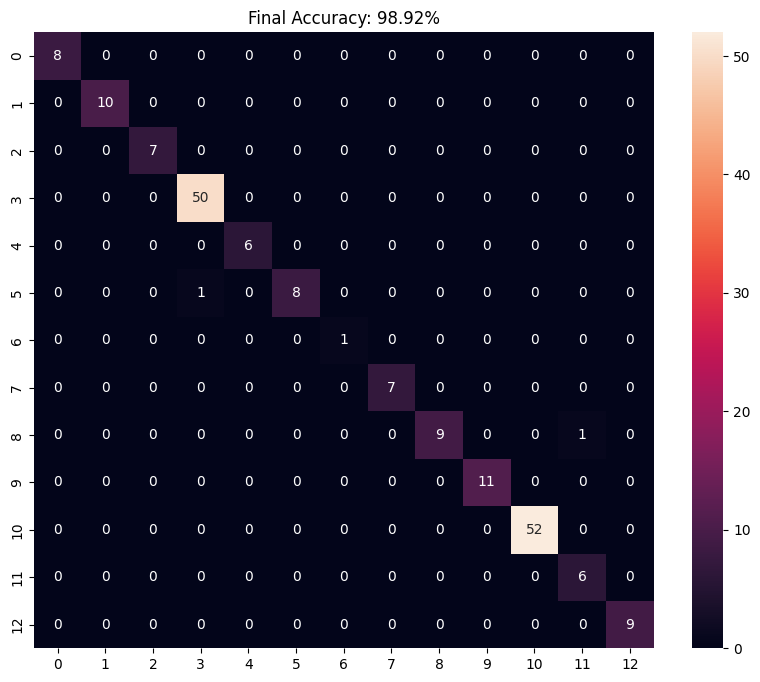

In [5]:
# EXTRACT FEATURES
print("Loading DINOv2...")
dino = torch.hub.load('facebookresearch/dinov2', 'dinov2_vits14').to(DEVICE)
dino.eval()

def get_features(loader):
    feats, labels = [], []
    with torch.no_grad():
        for imgs, lbls in tqdm(loader, desc="Extracting"):
            imgs = imgs.to(DEVICE)
            output = dino(imgs).cpu().numpy()
            feats.append(output)
            labels.append(lbls.numpy())
    return np.concatenate(feats), np.concatenate(labels)


print("Processing Training Data...")
X_train, y_train = get_features(train_loader)
print("Processing Test Data...")
X_test, y_test   = get_features(val_loader)

# Normalize
X_train_norm = normalize(X_train, norm='l2')
X_test_norm  = normalize(X_test, norm='l2')


# TRAIN OCCUPANCY CLASSIFIER

print(" Training Occupancy CLASSIFIER ")

if 'empty' in train_data.class_to_idx:
    empty_idx = train_data.class_to_idx['empty']
else:
    raise ValueError("Dataset does not have an 'empty' folder!")

y_train_occ = (y_train != empty_idx).astype(int)
y_test_occ  = (y_test != empty_idx).astype(int)


clf_occupancy = SVC(kernel='rbf', C=10, gamma='scale', probability=True)
clf_occupancy.fit(X_train_norm, y_train_occ)

# Evaluate OCCUPANCY CLASSIFIER
y_pred_occ_binary = clf_occupancy.predict(X_test_norm)
acc_occ = accuracy_score(y_test_occ, y_pred_occ_binary)
print(f"Occupancy CLASSIFIER Accuracy: {acc_occ*100:.2f}%")


# TRAIN PIECE CLASSIFIER
print(" Training Piece CLASSIFIER ")

piece_mask = y_train != empty_idx
X_train_pieces = X_train_norm[piece_mask]
y_train_pieces = y_train[piece_mask]


clf_piece = SVC(kernel='linear', C=10, probability=True,class_weight='balanced')
clf_piece.fit(X_train_pieces, y_train_pieces)


final_predictions = []
confidence_scores = [] 

empty_class_idx = empty_idx
piece_classes = clf_piece.classes_ 

for i in range(len(X_test_norm)):

    # proba returns [Prob_Empty, Prob_Occupied]
    occ_probs = clf_occupancy.predict_proba([X_test_norm[i]])[0]
    
    prob_empty = occ_probs[0]
    prob_occupied = occ_probs[1]
    
    # must be > 0.7 to be occupied
    if prob_occupied > 0.7:
        
        # piece Probability
        piece_probs = clf_piece.predict_proba([X_test_norm[i]])[0]
        
        # Find the max probability and the corresponding class index
        max_piece_prob = np.max(piece_probs)
        predicted_piece_idx = piece_classes[np.argmax(piece_probs)]
        
        
        if max_piece_prob < 0.45: # If piece confidence is very low
             final_predictions.append(empty_class_idx)
             confidence_scores.append(prob_empty) # Revert to empty confidence
        else:
             final_predictions.append(predicted_piece_idx)
             confidence_scores.append(max_piece_prob)
             
    else:
        final_predictions.append(empty_class_idx)
        confidence_scores.append(prob_empty)

y_pred_final = np.array(final_predictions)


acc_final = accuracy_score(y_test, y_pred_final)
print(f"FINAL CASCADED ACCURACY: {acc_final*100:.2f}%")


print("Classification Report:")
print(classification_report(y_test, y_pred_final, target_names=train_data.classes, labels=np.unique(y_test)))

plt.figure(figsize=(10,8))
sns.heatmap(confusion_matrix(y_test, y_pred_final, labels=np.unique(y_test)), 
            annot=True, fmt='d', xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
plt.title(f"Final Accuracy: {acc_final*100:.2f}%")
plt.show()

# Save the Model


In [6]:
import joblib

# Save the models and the class names
joblib.dump(clf_occupancy, 'models/model_occupancy.pkl')
joblib.dump(clf_piece, 'models/model_piece.pkl')
joblib.dump(train_data.classes, 'models/model_classes.pkl')

print(" Models saved")

 Models saved
